# Wisconsin Breast Cancer Dataset — XGBoost Model
Load the dataset, preprocess with standard scaling, split into training and test sets, train an XGBoost classifier, and evaluate model performance.


Loaded dataset with 569 samples and 30 features.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:58:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


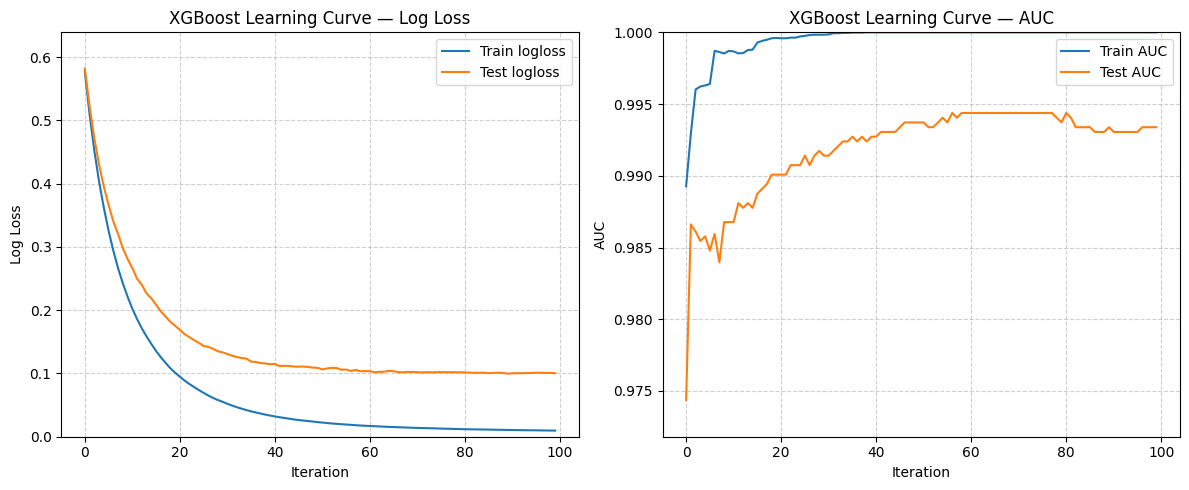

Test Accuracy: 0.9474
ROC AUC: 0.9934

Classification report:
              precision    recall  f1-score   support

   malignant       0.95      0.90      0.93        42
      benign       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



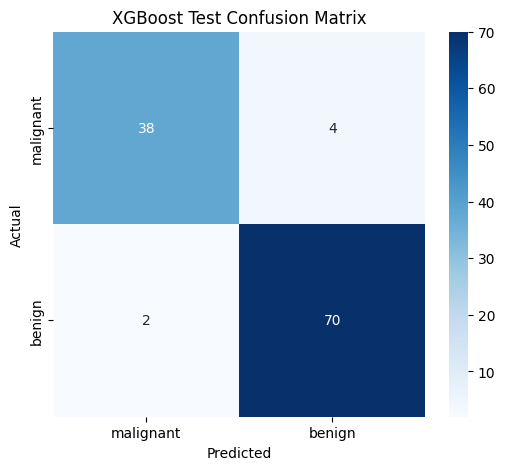

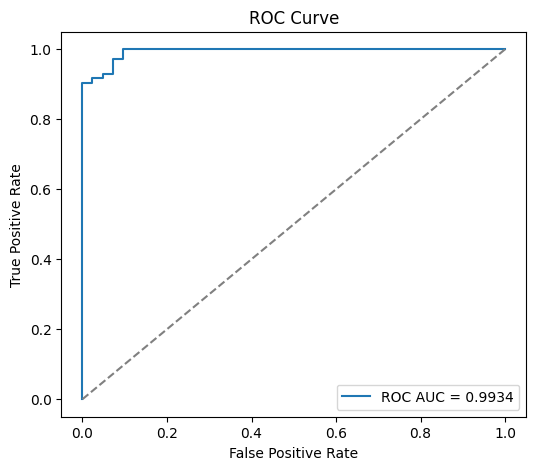

<Figure size 1000x500 with 0 Axes>

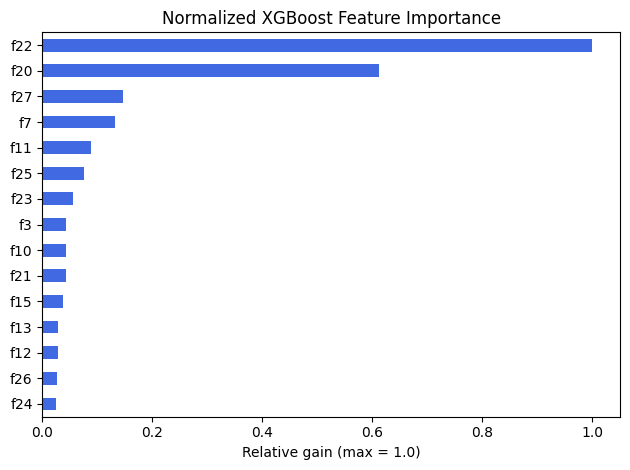

<Figure size 640x480 with 0 Axes>

In [16]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
import seaborn as sns

try:
    import xgboost as xgb
except ImportError:
    import sys
    !{sys.executable} -m pip install xgboost
    import xgboost as xgb

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")
print(f"Loaded dataset with {X.shape[0]} samples and {X.shape[1]} features.")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric=["logloss", "auc"],
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
)

eval_set = [(X_train_scaled, y_train), (X_test_scaled, y_test)]
model.fit(
    X_train_scaled,
    y_train,
    eval_set=eval_set,
    verbose=False,
)

results = model.evals_result()
train_logloss = results["validation_0"]["logloss"]
test_logloss = results["validation_1"]["logloss"]
train_auc = results["validation_0"]["auc"]
test_auc = results["validation_1"]["auc"]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_logloss, label="Train logloss")
plt.plot(test_logloss, label="Test logloss")
plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.title("XGBoost Learning Curve — Log Loss")
logloss_min = min(min(train_logloss), min(test_logloss))
logloss_max = max(max(train_logloss), max(test_logloss))
logloss_range = logloss_max - logloss_min
plt.ylim(max(0, logloss_min - 0.1 * logloss_range), logloss_max + 0.1 * logloss_range)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(train_auc, label="Train AUC")
plt.plot(test_auc, label="Test AUC")
plt.xlabel("Iteration")
plt.ylabel("AUC")
plt.title("XGBoost Learning Curve — AUC")
auc_min = min(min(train_auc), min(test_auc))
auc_max = max(max(train_auc), max(test_auc))
auc_range = auc_max - auc_min
plt.ylim(max(0.9, auc_min - 0.1 * auc_range), 1.0)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Test Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob), 4))
print()
print("Classification report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=data.target_names, yticklabels=data.target_names)
plt.title("XGBoost Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_test, y_prob):.4f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
importance_dict = model.get_booster().get_score(importance_type="gain")
importance_df = pd.DataFrame.from_dict(importance_dict, orient="index", columns=["gain"]).sort_values("gain", ascending=True)
importance_df["gain_norm"] = importance_df["gain"] / importance_df["gain"].max()
importance_df.tail(15).plot.barh(y="gain_norm", legend=False, color="royalblue")
plt.xlabel("Relative gain (max = 1.0)")
plt.title("Normalized XGBoost Feature Importance")
plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()


In [19]:
import optuna
from sklearn.model_selection import StratifiedKFold
import warnings
optuna.logging.set_verbosity(optuna.logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)
from sklearn.metrics import roc_auc_score, f1_score

def objective(trial):
    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "n_estimators": trial.suggest_int("n_estimators", 50, 300, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
        "random_state": 42,
        "n_jobs": -1,
    }
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1_scores = []
    for train_idx, valid_idx in cv.split(X_train_scaled, y_train):
        X_train_fold = X_train_scaled[train_idx]
        y_train_fold = y_train.iloc[train_idx]
        X_valid_fold = X_train_scaled[valid_idx]
        y_valid_fold = y_train.iloc[valid_idx]
        model_opt = xgb.XGBClassifier(**params)
        model_opt.fit(
            X_train_fold,
            y_train_fold,
            eval_set=[(X_valid_fold, y_valid_fold)],
            verbose=False,
        )
        y_valid_pred = model_opt.predict(X_valid_fold)
        f1_scores.append(f1_score(y_valid_fold, y_valid_pred))
    return np.mean(f1_scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=25, show_progress_bar=False)

print("Best validation F1:", round(study.best_value, 4))
print("Best params:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

best_params = study.best_params
best_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric=["logloss", "auc"],
    random_state=42,
    n_jobs=-1,
    **best_params,
)

best_model.fit(
    X_train_scaled,
    y_train,
    eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
    verbose=False,
)

model = best_model
results = model.evals_result()
train_logloss = results["validation_0"]["logloss"]
test_logloss = results["validation_1"]["logloss"]
train_auc = results["validation_0"]["auc"]
test_auc = results["validation_1"]["auc"]

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Best model test accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Best model ROC AUC:", round(roc_auc_score(y_test, y_prob), 4))
print()
print("Best model classification report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))
cm_best = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Blues", xticklabels=data.target_names, yticklabels=data.target_names)
plt.title("Best Model Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Best validation AUC: 0.9907
Best params:
  n_estimators: 250
  max_depth: 5
  learning_rate: 0.0366546366030449
  subsample: 0.5062608422269375
  colsample_bytree: 0.8277274870093884
  gamma: 0.016524508456385645
  reg_alpha: 3.2283370787526184
  reg_lambda: 1.278333559107745
Best model test accuracy: 0.9474
Best model ROC AUC: 0.9931

Best model classification report:
              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        42
      benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [ ]:
cm_best = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Blues", xticklabels=data.target_names, yticklabels=data.target_names)
plt.title("Best Model Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


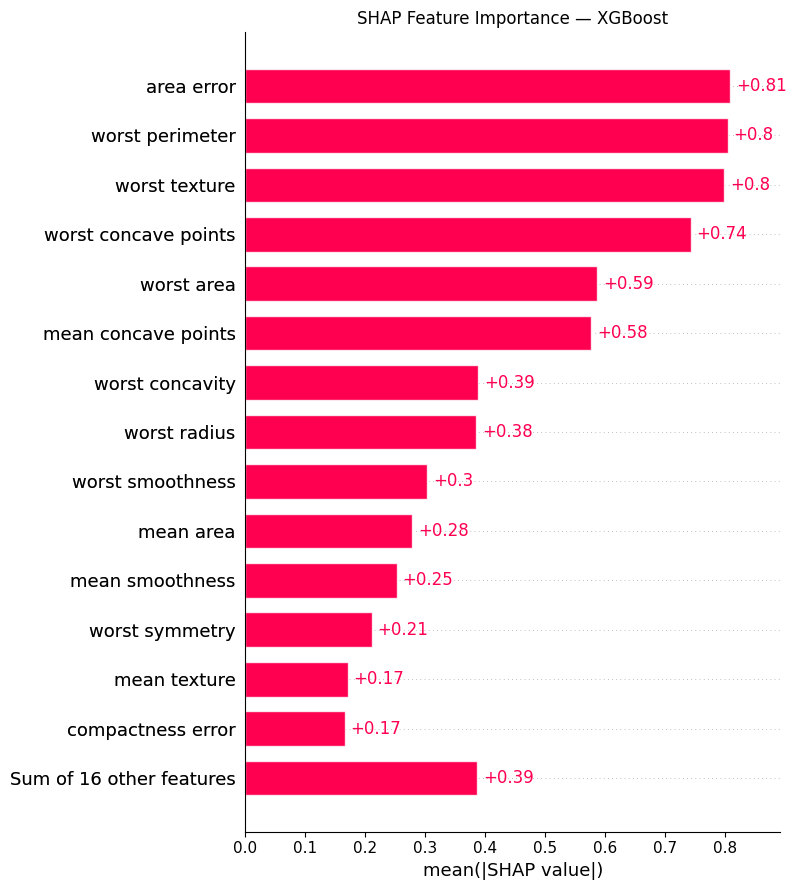

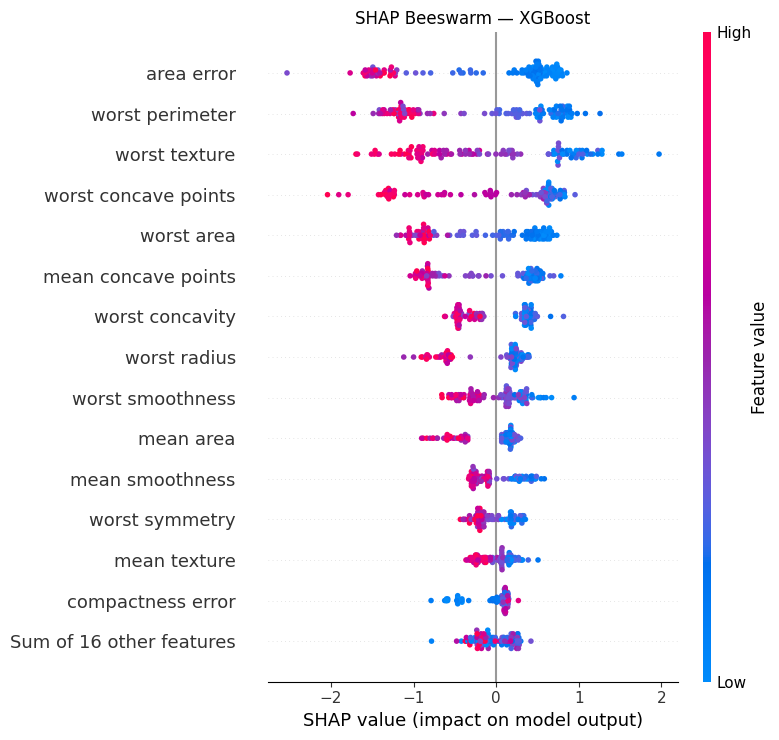

In [17]:
try:
    import shap
except ImportError:
    import sys
    !{sys.executable} -m pip install shap
    import shap

explainer = shap.Explainer(model, X_train_scaled, feature_names=list(X.columns))
shap_values = explainer(X_test_scaled)

plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("SHAP Feature Importance — XGBoost")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("SHAP Beeswarm — XGBoost")
plt.tight_layout()
plt.show()
